In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
from scvi.external import MRVI
from plotnine import *


/home/melrie/miniforge3/envs/compare/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# 1. Load your "Fresh" data
adata = sc.read_h5ad("/home/melrie/human_intestinal/data/adata_clean.h5ad")

# 2. Load Model A
model_mrvi = MRVI.load("/home/melrie/human_intestinal/outputs/models/mrvi_model_153/", adata=adata) #final mrvi model from job 153
adata


INFO     File /home/melrie/human_intestinal/outputs/models/mrvi_model_153/model.pt already downloaded              


/tmp/ipykernel_1946509/1627590808.py:5: UserWarning: MRVI model is being loaded with PyTorch backend
/home/melrie/miniforge3/envs/compare/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/melrie/miniforge3/envs/compare/lib/python3.11/ ...


AnnData object with n_obs × n_vars = 701840 × 18293
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'donor_disease_category', '_indices', '_scvi_sample', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length

In [ ]:
model_scvi = scvi.model.SCVI.load("/home/melrie/human_intestinal/outputs/models/scvi_model_160/", adata=adata) # final scvi model from job 160

adata

INFO     File /home/melrie/human_intestinal/outputs/models/scvi_model_160/model.pt already downloaded              


/home/melrie/miniforge3/envs/compare/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/melrie/miniforge3/envs/compare/lib/python3.11/ ...


AnnData object with n_obs × n_vars = 701840 × 18293
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'donor_disease_category', '_indices', '_scvi_sample', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length

In [5]:
adata.obsm["X_mrVI_u"] = model_mrvi.get_latent_representation()
adata.obsm["X_mrVI_z"] = model_mrvi.get_latent_representation(give_z=True)
adata

AnnData object with n_obs × n_vars = 701840 × 18293
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'donor_disease_category', '_indices', '_scvi_sample', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length

In [ ]:
SCVI_LATENT_KEY = "X_scVI"

latent = model_scvi.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent


(701840, 10)

In [7]:
sc.pp.neighbors(adata, use_rep="X_mrVI_u", key_added="neighbors_mrvi_u")
sc.pp.neighbors(adata, use_rep="X_mrVI_z", key_added="neighbors_mrvi_z")
sc.pp.neighbors(adata, use_rep="X_scVI", key_added="neighbors_scvi")

In [8]:
sc.tl.umap(adata, neighbors_key="neighbors_mrvi_u")
adata.obsm["X_umap_mrvi_u"] = adata.obsm["X_umap"].copy()
del adata.obsm["X_umap"]

In [9]:
sc.tl.umap(adata, neighbors_key="neighbors_mrvi_z")
adata.obsm["X_umap_mrvi_z"] = adata.obsm["X_umap"].copy()
del adata.obsm["X_umap"]

In [10]:
sc.tl.umap(adata, neighbors_key="neighbors_scvi")
adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()
del adata.obsm["X_umap"]

In [11]:
adata

AnnData object with n_obs × n_vars = 701840 × 18293
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'donor_disease_category', '_indices', '_scvi_sample', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length

In [13]:
adata.write_h5ad("/home/melrie/human_intestinal/data/adata_mrvi_scvi.h5ad")

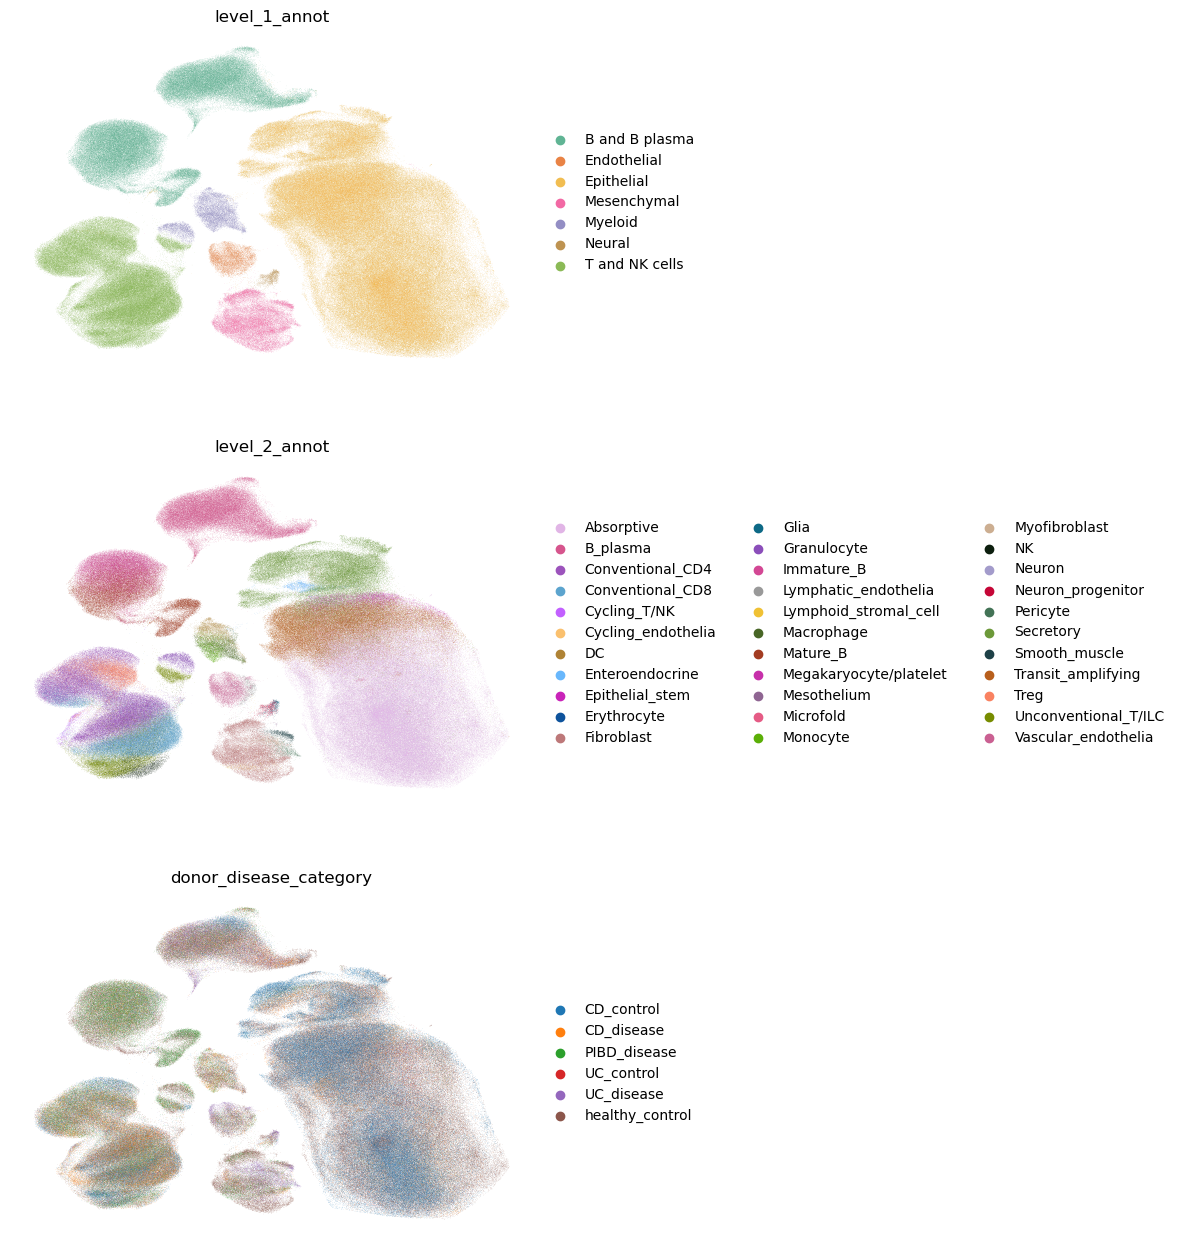

In [14]:
color_by = ["level_1_annot", "level_2_annot", "donor_disease_category"]
embeddings = "X_umap_mrvi_u"

sc.pl.embedding(
    adata, 
    basis=embeddings, 
    color=color_by, 
    ncols=1, 
    frameon=False,
    title=color_by
)

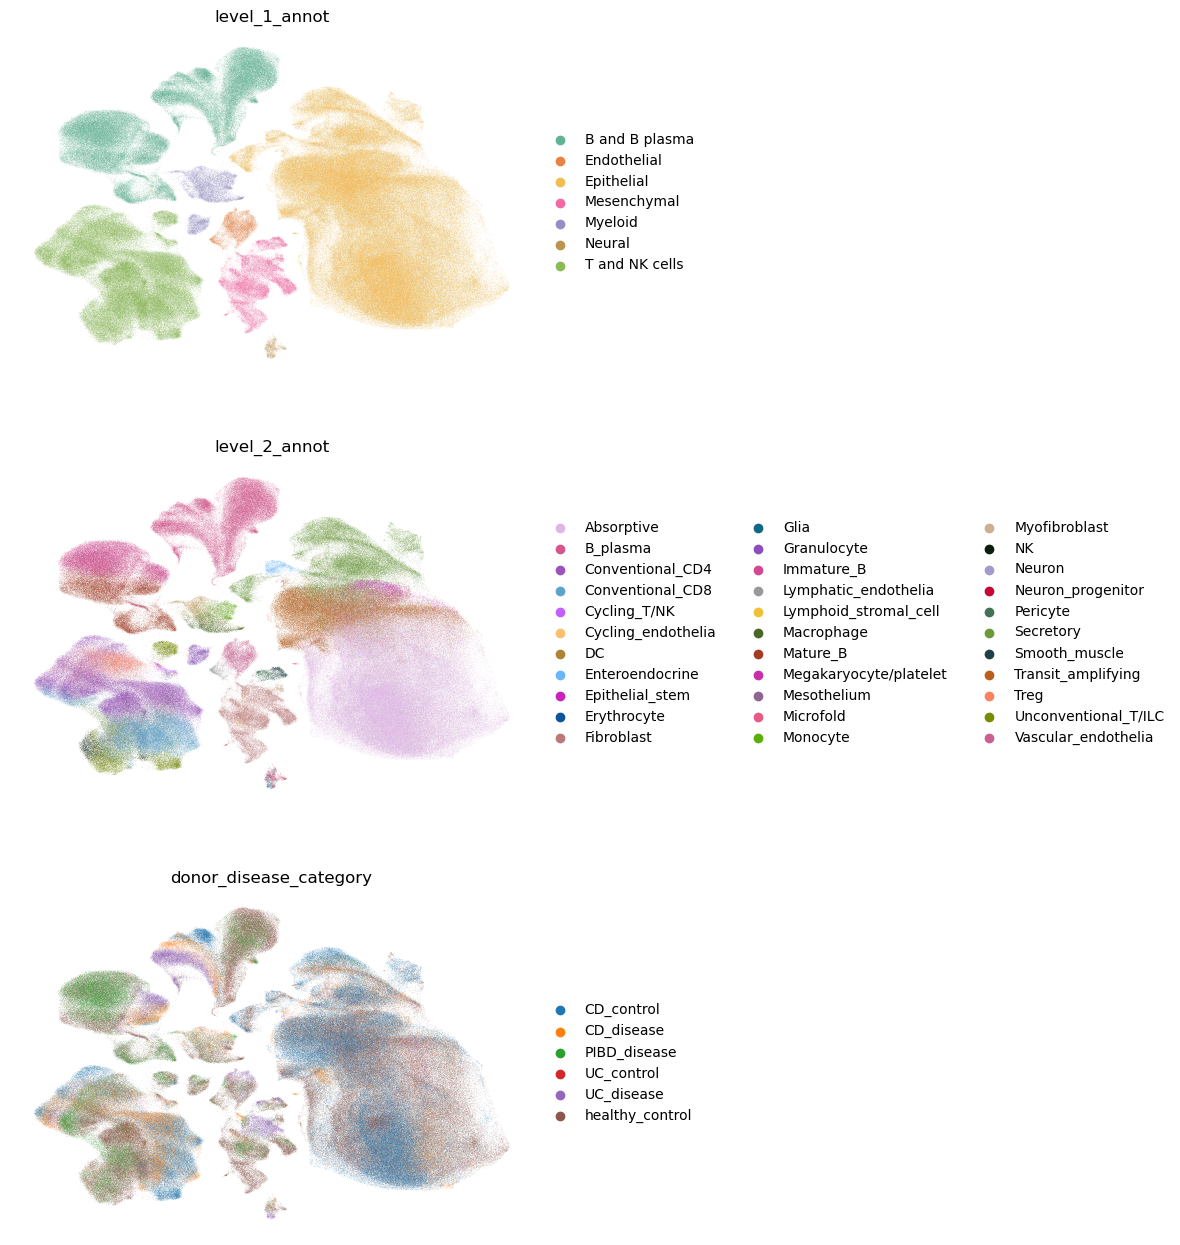

In [15]:
color_by = ["level_1_annot", "level_2_annot", "donor_disease_category"]
embeddings = "X_umap_mrvi_z"

sc.pl.embedding(
    adata, 
    basis=embeddings, 
    color=color_by, 
    ncols=1, 
    frameon=False,
    title=color_by
)

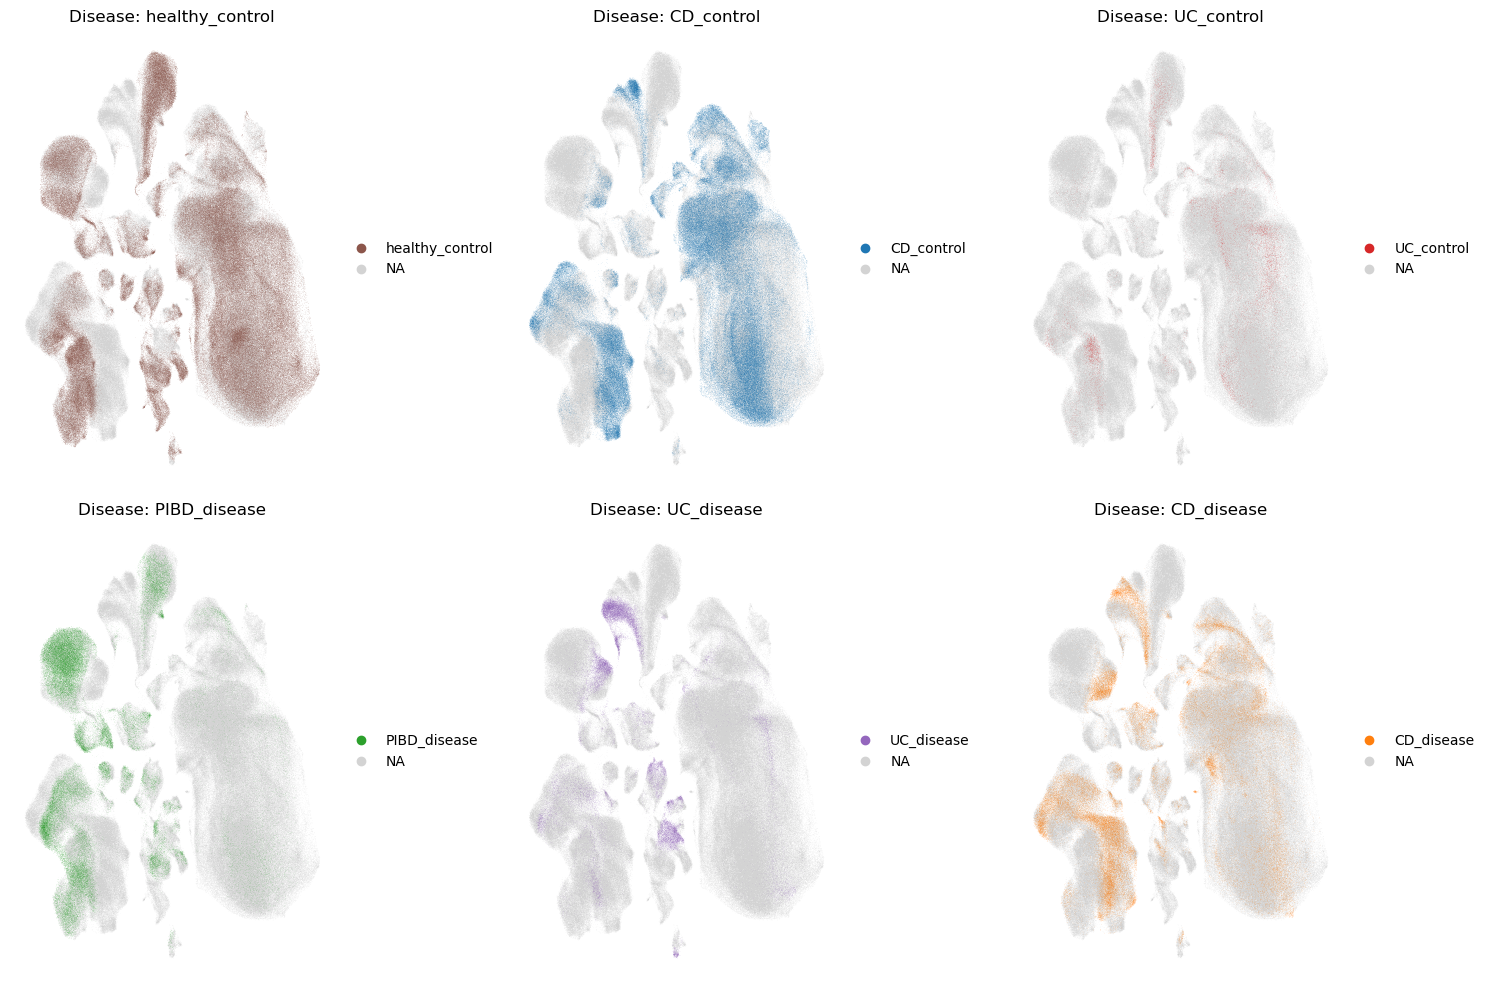

In [ ]:
import matplotlib.pyplot as plt
import math

# 1. Setup your data
target_col = "donor_disease_category"
cats = adata.obs[target_col].unique().tolist()
ncols = 3
nrows = math.ceil(len(cats) / ncols)

# 2. Create the figure and axes grid
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
axes = axes.flatten()  # Makes it a 1D array so we can loop easily

# 3. Loop through categories and plot on each axis
for i, cat in enumerate(cats):
    sc.pl.embedding(
        adata, 
        basis=embeddings, 
        color=target_col, 
        groups=[cat],       # Highlight only this category
        ax=axes[i],         # Put it in the current subplot
        show=False,         # Don't show until the whole grid is done
        frameon=False,
        title=f"Disease: {cat}"
    )

# 4. Clean up: Hide empty subplots if cats < (nrows * ncols)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Extract the coordinates and metadata into a DataFrame
# Replace 'X_umap_mrvi_z' with the exact key in your adata.obsm
umap_coords = adata.obsm[embeddings]

plot_df = pd.DataFrame(
    umap_coords[:, :2], 
    columns=['UMAP1', 'UMAP2'], 
    index=adata.obs_names
)

# 2. Add the metadata column you want to see on hover
plot_df['category'] = adata.obs['donor_disease_category'].values

# 3. Create the interactive scatter plot
fig = px.scatter(
    plot_df, 
    x='UMAP1', 
    y='UMAP2', 
    color='category',
    hover_name=plot_df.index,      # Shows the cell ID/barcode
    hover_data=['category'],       # Shows the disease category
    template='simple_white',
    title='Interactive UMAP: Hover to see Category',
    width=800, 
    height=600
)

# 4. Make the points smaller for better visibility (optional)
fig.update_traces(marker=dict(size=4, opacity=0.7))

fig.show()

ModuleNotFoundError: No module named 'plotly'